--- Data Structure Inspection ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB

Missing values per column:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit

/tmp/ipykernel_827/2024556317.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(K_range, inertia, 'bx-', color='#2b5c8f', linewidth=2)


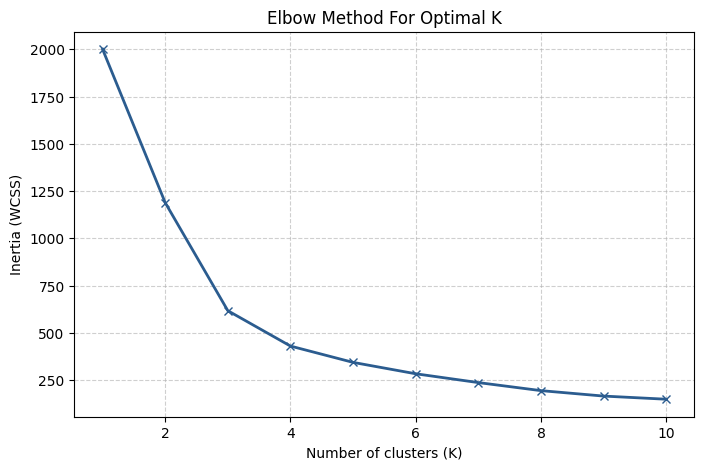


--- Final Customer Segments Profile ---
 Cluster    Recency    Monetary       Age  Customer Count
       0 270.521429 1283.571429 39.228571             140
       1  92.116216  159.770270 41.532432             370
       2 274.573770  148.319672 42.153005             366
       3  84.935484 1313.709677 41.169355             124


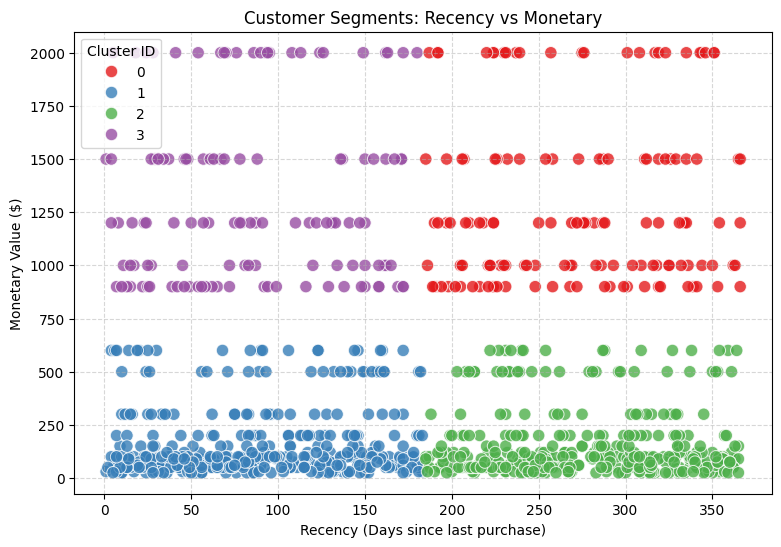

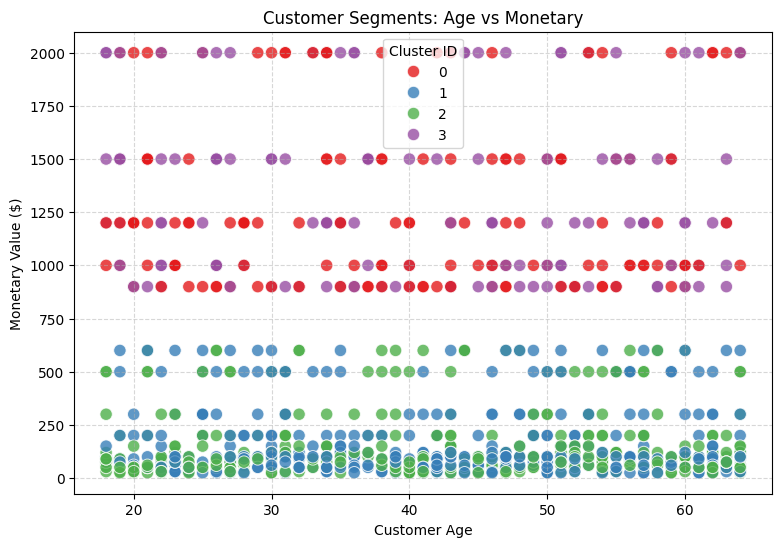

/tmp/ipykernel_827/2024556317.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_profile, x='Cluster', y='Customer Count', palette='Set1')


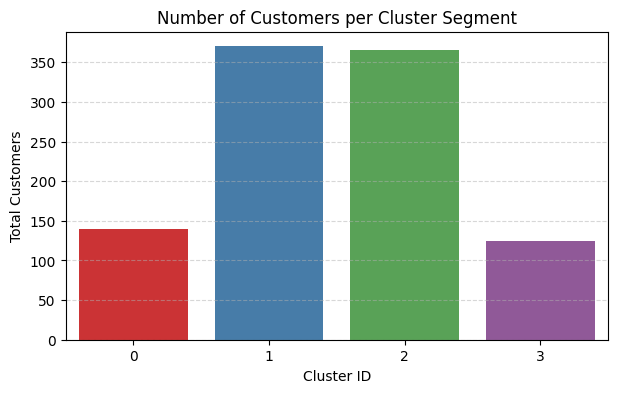

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load dataset from your Google Drive path
file_path = '/content/drive/MyDrive/Colab Notebooks/OIBSIPDataAnalytics-L1-EDARetailSales/retail_sales_dataset.csv'
df = pd.read_csv(file_path)

# Handle date formats securely
df['Date'] = pd.to_datetime(df['Date'])

print("--- Data Structure Inspection ---")
df.info()
print("\nMissing values per column:\n", df.isnull().sum())

# 2. Descriptive Statistics
avg_purchase_value = df['Total Amount'].mean()
purchase_frequency = df['Customer ID'].value_counts().mean()
customer_lifetime_value = df.groupby('Customer ID')['Total Amount'].sum().mean()

print("\n--- Baseline Statistics ---")
print(f"Average Purchase Value: ${avg_purchase_value:.2f}")
print(f"Purchase Frequency per Customer: {purchase_frequency:.2f}")
print(f"Customer Lifetime Value (Mean): ${customer_lifetime_value:.2f}")

# 3. Feature Selection / RFM Analysis
# Setting reference date to max date + 1 day to measure Recency accurately
max_date = df['Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'Date': lambda x: (max_date - x.max()).days,
    'Total Amount': 'sum',
    'Age': 'mean'
}).rename(columns={'Date': 'Recency', 'Total Amount': 'Monetary'})

# Frequency is 1.0 globally for this data, so we drop it from clustering features
features = ['Recency', 'Monetary']

# 4. Data Standardisation
scaler = StandardScaler()
scaled_features = scaler.fit_transform(rfm[features])

# 5. Elbow Method to Determine Optimal K
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

# Generate and display Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bx-', color='#2b5c8f', linewidth=2)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method For Optimal K')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('elbow_method.png')
plt.show()

# 6. Apply Final K-Means Clustering (K=4 yields ideal behavioral quadrants)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(scaled_features)

# 7. Profile Each Cluster
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Monetary': 'mean',
    'Age': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Customer Count'}).reset_index()

print("\n--- Final Customer Segments Profile ---")
print(cluster_profile.to_string(index=False))

# 8. Cluster Visualizations
# Combination 1: Recency vs Monetary Scatter Plot
plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1', s=80, alpha=0.8)
plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Monetary Value ($)')
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('scatter_recency_monetary.png')
plt.show()

# Combination 2: Age vs Monetary Scatter Plot
plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm, x='Age', y='Monetary', hue='Cluster', palette='Set1', s=80, alpha=0.8)
plt.title('Customer Segments: Age vs Monetary')
plt.xlabel('Customer Age')
plt.ylabel('Monetary Value ($)')
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('scatter_age_monetary.png')
plt.show()

# Bar Chart: Number of Customers per Cluster
plt.figure(figsize=(7, 4))
sns.barplot(data=cluster_profile, x='Cluster', y='Customer Count', palette='Set1')
plt.title('Number of Customers per Cluster Segment')
plt.xlabel('Cluster ID')
plt.ylabel('Total Customers')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('bar_customers_per_cluster.png')
plt.show()